In [24]:
import json
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import RFECV, VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier

os.makedirs("data/processed", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("config", exist_ok=True)

In [25]:
TRANSFORMS = {
    "interaction_risk": "log1p",
    "progressive_risk": "log1p",
    "interaction_risk_ema3": "log1p",
    "toxicity_score": "log1p",
    "interaction_risk_rolling3_mean": "log1p",
    "mean_risk_so_far": "log1p",
    "interaction_risk_rolling3_max": "log1p",
    "toxicity_score_ema3": "log1p",
    "toxicity_score_rolling3_mean": "log1p",
    "toxicity_score_rolling3_max": "log1p",
    "max_toxicity_so_far": "log1p",
    "threat_score": "log1p",
    "threat_score_ema3": "log1p",
    "threat_score_rolling3_mean": "log1p",
    "threat_score_rolling3_max": "log1p",
    "max_threat_so_far": "log1p",
    "late_risk_increase": "log1p",
    "early_high_risk": "log1p",
    "risk_slope_3": "square",
    "toxicity_diff": "square",
    "toxicity_accel": "square",
    "threat_diff": "square",
    "prev_progressive": "log1p",
    "state_input_similarity": "yeo-johnson",
    "long_term_state_similarity": "log1p",
    "long_term_state_drift": "log1p",
    "state_input_distance": "log1p",
    "drift_acceleration": "log1p",
    "state_similarity": "binarize",
    "topic_drift_score": "log1p",
    "pattern_risk": "binarize",
    "pattern_risk_ema3": "binarize",
    "pattern_risk_rolling3_mean": "log1p",
    "pattern_risk_rolling3_max": "binarize",
}

In [26]:
def conversation_split(df):
    all_conv_ids = df["conv_id"].unique()
    train_val_ids, test_ids = train_test_split(all_conv_ids, test_size=0.2, random_state=42, shuffle=True)
    train_ids, val_ids = train_test_split(train_val_ids, test_size=0.25, random_state=42, shuffle=True)

    train_df = df[df["conv_id"].isin(train_ids)].reset_index(drop=True)
    val_df = df[df["conv_id"].isin(val_ids)].reset_index(drop=True)
    test_df = df[df["conv_id"].isin(test_ids)].reset_index(drop=True)

    return {"train": train_df, "val": val_df, "test": test_df}


def remove_multicollinear(X_train, y_train, threshold):
    corr_df = X_train.copy()
    corr_df["target"] = y_train.values
    corr_matrix = corr_df.corr()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_remove = set()
    for col in upper.columns:
        if col == "target":
            continue
        highly_correlated = upper.index[abs(upper[col]) > threshold].tolist()
        for other_col in highly_correlated:
            if other_col == "target" or other_col in to_remove or col in to_remove:
                continue
            corr_col = abs(corr_matrix.loc[col, "target"])
            corr_other_col = abs(corr_matrix.loc[other_col, "target"])
            if corr_col >= corr_other_col:
                to_remove.add(other_col)
            else:
                to_remove.add(col)

    cols_to_keep = [c for c in X_train.columns if c not in to_remove]
    return cols_to_keep


def save_split(X, meta, y, path):
    out = X.copy()
    out["conv_id"] = meta["conv_id"].values
    out["turn_id"] = meta["turn_id"].values
    out["label"] = y.values
    out.to_csv(path, index=False)
    print(f"Saved {path}  shape={out.shape}")


def transform_feature(series, transform):
    if transform == "log1p":
        return np.log1p(np.maximum(series, 0))
    if transform == "square":
        return np.square(series)
    return series


def apply_transform(df):
    df = df.copy()
    for feature, transform in TRANSFORMS.items():
        if feature not in df.columns:
            continue
        df[f"{feature}"] = transform_feature(df[feature], transform)
    return df

In [27]:

train_df= pd.read_csv("../data/merged/train_df.csv")
val_df= pd.read_csv("../data/merged/val_df.csv")
test_df= pd.read_csv("../data/merged/test_df.csv")



embedding_cols = [c for c in train_df.columns if c.strip().isdigit()]



print(f"Excluding {len(embedding_cols)} embedding columns")

feature_cols = [c for c in train_df.columns if c not in embedding_cols]

train_df_trans = apply_transform(train_df[feature_cols])
val_df_trans = apply_transform(val_df[feature_cols])
test_df_trans = apply_transform(test_df[feature_cols])

feature_cols = [c for c in train_df_trans.columns if c not in ["conv_id", "turn_id", "label"]]

meta_train= train_df[["conv_id","turn_id"]]
meta_val= val_df[["conv_id","turn_id"]]
meta_test= test_df[["conv_id","turn_id"]]

X_train= train_df_trans[feature_cols]
X_val= val_df_trans[feature_cols]
X_test= test_df_trans[feature_cols]

y_train= train_df["label"]
y_val= val_df["label"]
y_test= test_df["label"]

Excluding 1536 embedding columns


In [28]:
corr_vals = X_train.corrwith(y_train).abs().sort_values(ascending=False)
corr_vals

interaction_risk                  0.207677
progressive_risk                  0.207671
interaction_risk_rolling3_max     0.206786
interaction_risk_ema3             0.194670
interaction_risk_rolling3_mean    0.188009
mean_risk_so_far                  0.185122
max_toxicity_so_far               0.165304
toxicity_score_rolling3_max       0.163780
threat_score                      0.159204
toxicity_score                    0.159203
threat_score_rolling3_max         0.155275
threat_score_ema3                 0.154448
late_risk_increase                0.150748
max_threat_so_far                 0.149863
threat_score_rolling3_mean        0.148922
toxicity_score_ema3               0.142147
toxicity_score_rolling3_mean      0.136546
state_input_similarity            0.123826
prev_progressive                  0.120882
early_high_risk                   0.114315
threat_diff                       0.112041
risk_slope_3                      0.097687
toxicity_diff                     0.081180
pattern_ris

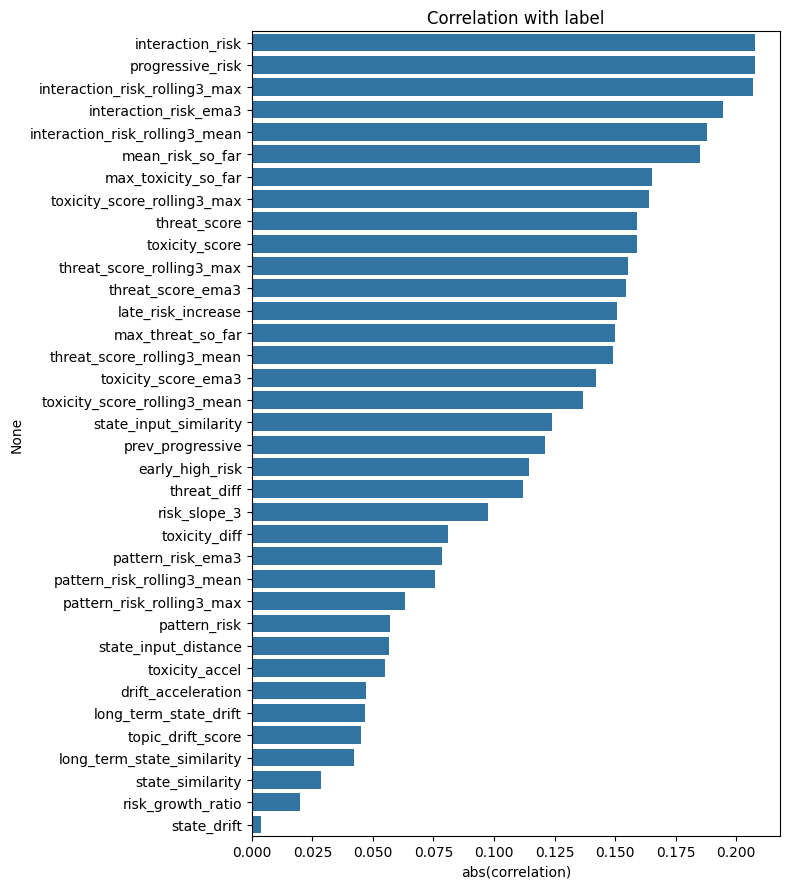

In [29]:
plt.figure(figsize=(8, max(4, len(corr_vals) * 0.25)))
sns.barplot(x=corr_vals.values, y=corr_vals.index)
plt.title("Correlation with label")
plt.xlabel("abs(correlation)")
plt.tight_layout()
plt.show()

In [30]:
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)
joblib.dump(scaler, "models/scaler.pkl")
X_train_scaled.head()

,state_drift,state_input_distance,long_term_state_drift,state_similarity,state_input_similarity,long_term_state_similarity,toxicity_score,threat_score,topic_drift_score,drift_acceleration,...,toxicity_diff,threat_diff,toxicity_accel,risk_slope_3,max_toxicity_so_far,max_threat_so_far,mean_risk_so_far,early_high_risk,late_risk_increase,risk_growth_ratio
0,-0.587392,0.621078,0.200460,0.167205,0.459865,-0.209191,-0.064619,-0.118318,0.952999,2.534235,...,0.021067,0.056988,195.141250,21.325913,3.185674,248.693235,18.875827,28.123408,-0.157160,-1.957123
1,0.932790,-0.682025,-0.821943,-0.885647,1.693195,0.633006,3.944750,4.895910,-0.621297,0.000000,...,-0.003074,-0.011554,-0.003733,-0.003088,2.066493,2.659983,3.076195,4.386194,3.242078,-0.820499
2,-0.441953,-0.582044,0.115503,0.118332,1.328282,-0.266396,-0.127715,-0.204081,0.915727,0.925279,...,0.015164,-0.009430,0.016582,-0.002876,-0.134734,-0.177993,-0.199919,-0.175455,-0.174524,0.293917
3,-0.625717,0.229993,0.393231,0.164620,0.458827,-0.978277,-0.090029,-0.191860,0.212371,0.929041,...,0.011778,-0.010942,0.003613,0.000739,-0.114364,-0.183727,-0.183010,-0.164368,-0.161216,0.241436
4,0.483916,-0.433116,-0.821943,-0.885647,-0.516474,0.633006,2.294041,0.388253,-0.621297,0.000000,...,-0.003074,-0.011554,-0.003733,-0.003088,1.174261,0.140516,1.328596,0.515752,0.888877,0.438590


In [31]:
var_sel = VarianceThreshold(threshold=0.05)
var_sel.fit(X_train_scaled)
var_cols = X_train_scaled.columns[var_sel.get_support()].tolist()
X_train_var = pd.DataFrame(var_sel.transform(X_train_scaled), columns=var_cols)
X_val_var = pd.DataFrame(var_sel.transform(X_val_scaled), columns=var_cols)
X_test_var = pd.DataFrame(var_sel.transform(X_test_scaled), columns=var_cols)
print(f"After variance filter: {len(var_cols)}")
var_cols

After variance filter: 36


['state_drift',
 'state_input_distance',
 'long_term_state_drift',
 'state_similarity',
 'state_input_similarity',
 'long_term_state_similarity',
 'toxicity_score',
 'threat_score',
 'topic_drift_score',
 'drift_acceleration',
 'interaction_risk',
 'pattern_risk',
 'progressive_risk',
 'prev_progressive',
 'toxicity_score_ema3',
 'toxicity_score_rolling3_mean',
 'toxicity_score_rolling3_max',
 'threat_score_ema3',
 'threat_score_rolling3_mean',
 'threat_score_rolling3_max',
 'interaction_risk_ema3',
 'interaction_risk_rolling3_mean',
 'interaction_risk_rolling3_max',
 'pattern_risk_ema3',
 'pattern_risk_rolling3_mean',
 'pattern_risk_rolling3_max',
 'toxicity_diff',
 'threat_diff',
 'toxicity_accel',
 'risk_slope_3',
 'max_toxicity_so_far',
 'max_threat_so_far',
 'mean_risk_so_far',
 'early_high_risk',
 'late_risk_increase',
 'risk_growth_ratio']

In [32]:
corr_vals = X_train_var.corrwith(y_train).abs().sort_values(ascending=False)
corr_vals

interaction_risk                  0.207677
progressive_risk                  0.207671
interaction_risk_rolling3_max     0.206786
interaction_risk_ema3             0.194670
interaction_risk_rolling3_mean    0.188009
mean_risk_so_far                  0.185122
max_toxicity_so_far               0.165304
toxicity_score_rolling3_max       0.163780
threat_score                      0.159204
toxicity_score                    0.159203
threat_score_rolling3_max         0.155275
threat_score_ema3                 0.154448
late_risk_increase                0.150748
max_threat_so_far                 0.149863
threat_score_rolling3_mean        0.148922
toxicity_score_ema3               0.142147
toxicity_score_rolling3_mean      0.136546
state_input_similarity            0.123826
prev_progressive                  0.120882
early_high_risk                   0.114315
threat_diff                       0.112041
risk_slope_3                      0.097687
toxicity_diff                     0.081180
pattern_ris

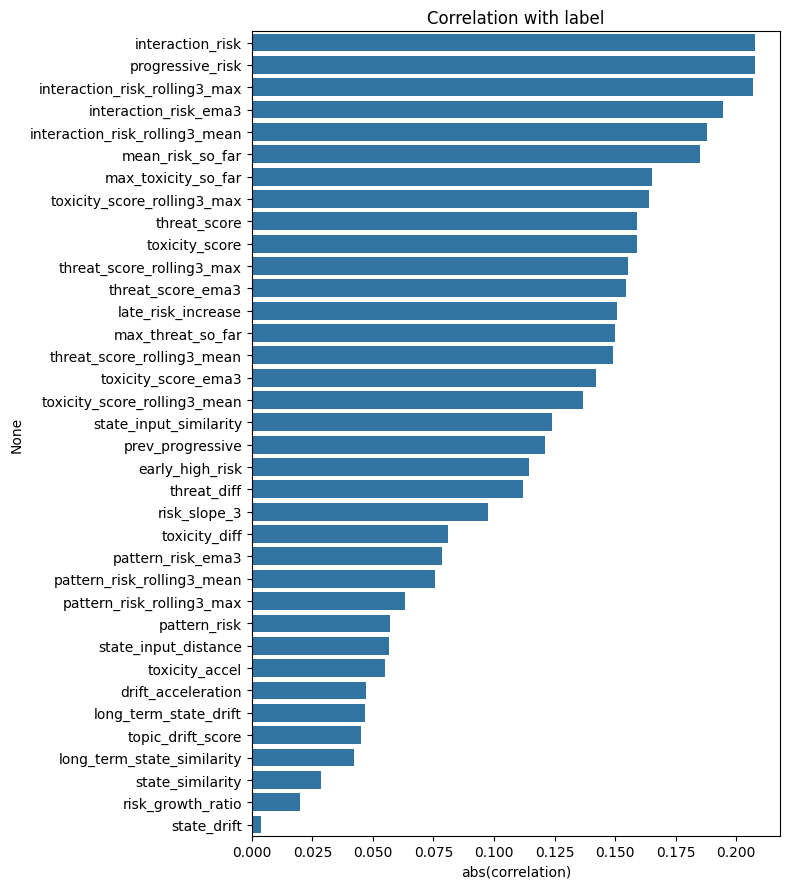

In [33]:
plt.figure(figsize=(8, max(4, len(corr_vals) * 0.25)))
sns.barplot(x=corr_vals.values, y=corr_vals.index)
plt.title("Correlation with label")
plt.xlabel("abs(correlation)")
plt.tight_layout()
plt.show()

In [34]:
corr_cols = corr_vals[corr_vals > 0.005].index.tolist()
X_train_corr = X_train_var[corr_cols]
X_val_corr = X_val_var[corr_cols]
X_test_corr = X_test_var[corr_cols]
print(f"After correlation filter: {len(corr_cols)}")

After correlation filter: 35


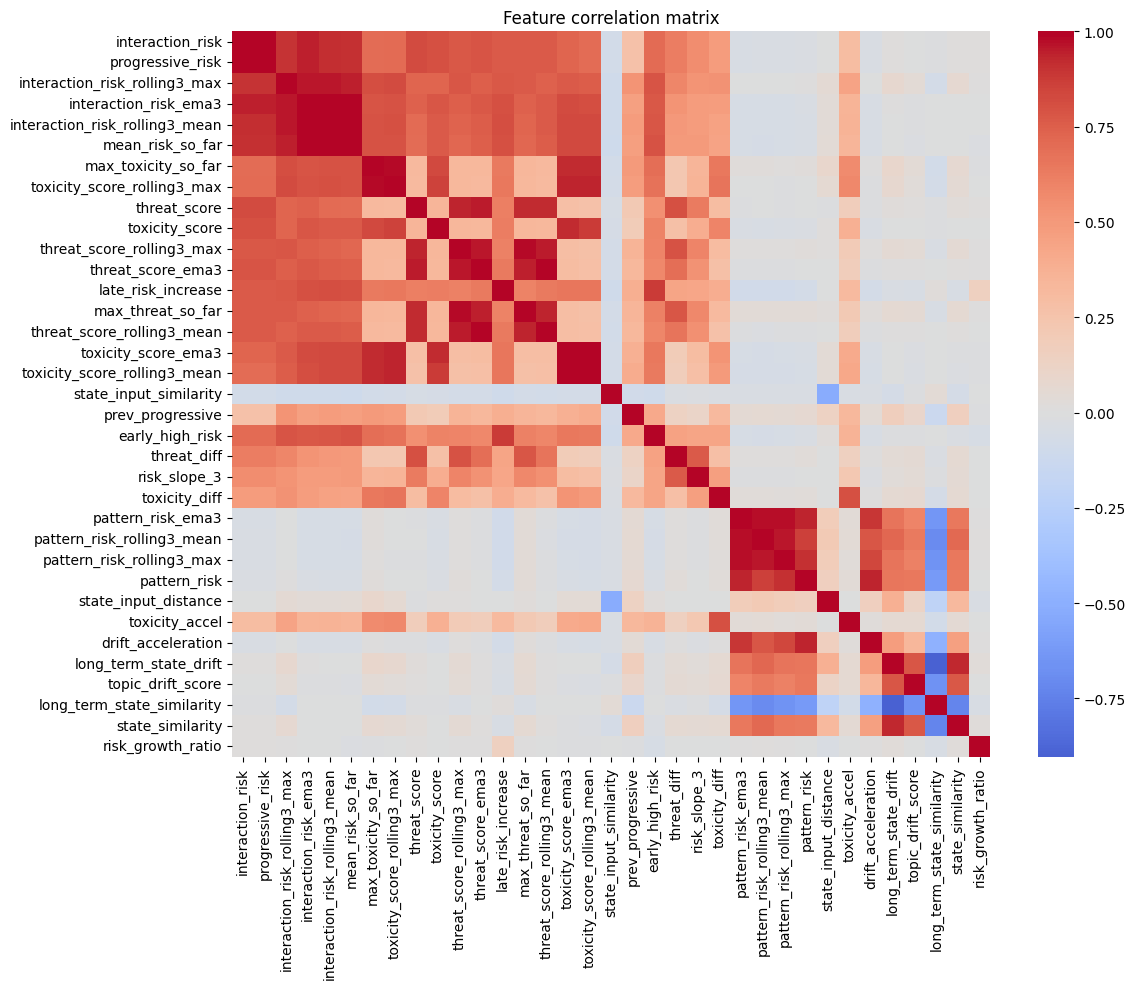

In [35]:
corr_matrix = X_train_corr.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

In [36]:
mc_cols = remove_multicollinear(X_train_corr, y_train, 0.9)
X_train_final = X_train_corr[mc_cols]
X_val_final = X_val_corr[mc_cols]
X_test_final = X_test_corr[mc_cols]
print(f"After multicollinearity: {len(mc_cols)}")
mc_cols

After multicollinearity: 19


['interaction_risk',
 'interaction_risk_rolling3_max',
 'max_toxicity_so_far',
 'threat_score',
 'toxicity_score',
 'late_risk_increase',
 'state_input_similarity',
 'prev_progressive',
 'early_high_risk',
 'threat_diff',
 'risk_slope_3',
 'toxicity_diff',
 'pattern_risk_ema3',
 'state_input_distance',
 'toxicity_accel',
 'drift_acceleration',
 'long_term_state_drift',
 'topic_drift_score',
 'risk_growth_ratio']

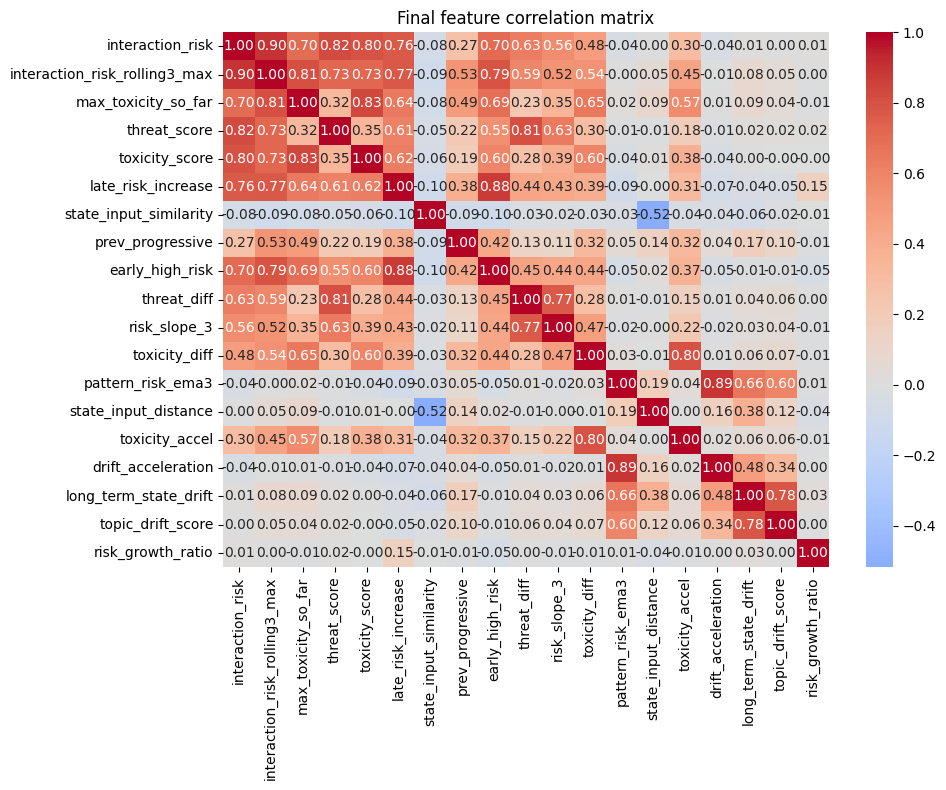

In [37]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train_final.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Final feature correlation matrix")
plt.tight_layout()
plt.show()

In [ ]:

X_train_final= pd.concat([X_train_final, train_df[embedding_cols]], axis=1)
X_val_final= pd.concat([X_val_final, val_df[embedding_cols]], axis=1)
X_test_final= pd.concat([X_test_final, test_df[embedding_cols]], axis=1)

save_split(X_train_final, meta_train, y_train, "data/processed/train.csv")
save_split(X_val_final, meta_val, y_val, "data/processed/validation.csv")
save_split(X_test_final, meta_test, y_test, "data/processed/test.csv")

with open("config/feature_info.json", "w") as f:
    json.dump({"selected_features": mc_cols, "scaler_path": "models/scaler.pkl"}, f, indent=4)

print(f"\nOriginal: {len(feature_cols)}  Final: {len(mc_cols)}")

Saved data/processed/train.csv  shape=(2636, 1558)
Saved data/processed/validation.csv  shape=(293, 1558)
Saved data/processed/test.csv  shape=(326, 1558)

Original: 36  Final: 19
